In [11]:
zip_path = "MyDataset.zip"


In [12]:
zip_path = "battery_project.zip"


In [13]:
zip_path = r"C:\Users\asus\Downloads\battery_project.zip"


In [14]:
import zipfile

zip_path = r"C:\Users\asus\Desktop\Smart_BMS_Project\MyDataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("MyDataset")

print("Dataset extracted successfully into MyDataset")



Dataset extracted successfully into MyDataset


In [15]:
import os

folder_name = "MyDataset"   
for root, dirs, files in os.walk(folder_name):
    print(root)
    for f in files:
        print("  ", f)


MyDataset
   final_battery_dataset.csv
MyDataset\cleaned_dataset
   combined_battery_dataset.csv
   metadata.csv
MyDataset\cleaned_dataset\data
   00001.csv
   00002.csv
   00003.csv
   00004.csv
   00005.csv
   00006.csv
   00007.csv
   00008.csv
   00009.csv
   00010.csv
   00011.csv
   00012.csv
   00013.csv
   00014.csv
   00015.csv
   00016.csv
   00017.csv
   00018.csv
   00019.csv
   00020.csv
   00021.csv
   00022.csv
   00023.csv
   00024.csv
   00025.csv
   00026.csv
   00027.csv
   00028.csv
   00029.csv
   00030.csv
   00031.csv
   00032.csv
   00033.csv
   00034.csv
   00035.csv
   00036.csv
   00037.csv
   00038.csv
   00039.csv
   00040.csv
   00041.csv
   00042.csv
   00043.csv
   00044.csv
   00045.csv
   00046.csv
   00047.csv
   00048.csv
   00049.csv
   00050.csv
   00051.csv
   00052.csv
   00053.csv
   00054.csv
   00055.csv
   00056.csv
   00057.csv
   00058.csv
   00059.csv
   00060.csv
   00061.csv
   00062.csv
   00063.csv
   00064.csv
   00065.csv
   00066.cs

In [16]:
import pandas as pd

sample_path = "MyDataset/cleaned_dataset/data/00001.csv"
df = pd.read_csv(sample_path)

print(df.head())      
print(df.columns)    
print(df.shape)       


   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time  
0         0.000   0.000  
1         4.262   9.360  
2         3.465  23.281  
3         3.451  36.406  
4         3.438  49.625  
Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time'],
      dtype='object')
(490, 6)


In [17]:
import glob
import os
import pandas as pd

# Path to all CSV files
csv_files = glob.glob("MyDataset/cleaned_dataset/data/*.csv")

# Combine all into one DataFrame
all_data = pd.concat((pd.read_csv(f).assign(source_file=os.path.basename(f)) for f in csv_files), ignore_index=True)

print("Combined dataset shape:", all_data.shape)
print(all_data.head())


Combined dataset shape: (7376834, 14)
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time source_file Sense_current Battery_current  \
0         0.000   0.000   00001.csv           NaN             NaN   
1         4.262   9.360   00001.csv           NaN             NaN   
2         3.465  23.281   00001.csv           NaN             NaN   
3         3.451  36.406   00001.csv           NaN             NaN   
4         3.438  49.625   00001.csv           NaN             NaN   

  Current_ratio Battery_impedance Rectified_Impedance  Current_charge  \
0          

In [18]:
all_data.to_csv("MyDataset/cleaned_dataset/combined_battery_dataset.csv", index=False)
print("Saved as combined_battery_dataset.csv")


Saved as combined_battery_dataset.csv


In [19]:
meta = pd.read_csv("MyDataset/cleaned_dataset/metadata.csv")
print(meta.head())


        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  00004.csv   
4                    4      B0047        4    5  00005.csv   

             Capacity                   Re                  Rct  
0  1.6743047446975208                  NaN                  NaN  
1                 NaN  0.05605783343888099  0.20097016584458333  
2                 NaN     

In [20]:
import pandas as pd

# Load the main combined dataset (from previous step)
combined_data = pd.read_csv("MyDataset/cleaned_dataset/combined_battery_dataset.csv")

# Load the metadata file
metadata = pd.read_csv("MyDataset/cleaned_dataset/metadata.csv")

print("Combined data shape:", combined_data.shape)
print("Metadata shape:", metadata.shape)

print("\n Combined data columns:")
print(combined_data.columns)

print("\n Metadata columns:")
print(metadata.columns)


Combined data shape: (7376834, 14)
Metadata shape: (7565, 10)

 Combined data columns:
Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time', 'source_file', 'Sense_current',
       'Battery_current', 'Current_ratio', 'Battery_impedance',
       'Rectified_Impedance', 'Current_charge', 'Voltage_charge'],
      dtype='object')

 Metadata columns:
Index(['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id',
       'uid', 'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')


In [21]:
merged_data = pd.merge(
    combined_data,
    metadata,
    left_on="source_file",    # column in combined data
    right_on="filename",     # column in metadata
    how="left"                # keep all main data, even if metadata missing
)

print("Merged dataset shape:", merged_data.shape)
print(merged_data.head())


Merged dataset shape: (7376834, 24)
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time source_file Sense_current Battery_current  \
0         0.000   0.000   00001.csv           NaN             NaN   
1         4.262   9.360   00001.csv           NaN             NaN   
2         3.465  23.281   00001.csv           NaN             NaN   
3         3.451  36.406   00001.csv           NaN             NaN   
4         3.438  49.625   00001.csv           NaN             NaN   

  Current_ratio  ...       type  \
0           NaN  ...  discharge   
1           NaN 

In [22]:
merged_data.to_csv("MyDataset/final_battery_dataset.csv", index=False)
print(" Final dataset saved as MyDataset/final_battery_dataset.csv")


 Final dataset saved as MyDataset/final_battery_dataset.csv


In [23]:

print(merged_data.columns)


Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time', 'source_file', 'Sense_current',
       'Battery_current', 'Current_ratio', 'Battery_impedance',
       'Rectified_Impedance', 'Current_charge', 'Voltage_charge', 'type',
       'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid',
       'filename', 'Capacity', 'Re', 'Rct'],
      dtype='object')


In [24]:

merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376834 entries, 0 to 7376833
Data columns (total 24 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Voltage_measured      float64
 1   Current_measured      float64
 2   Temperature_measured  float64
 3   Current_load          float64
 4   Voltage_load          float64
 5   Time                  float64
 6   source_file           object 
 7   Sense_current         object 
 8   Battery_current       object 
 9   Current_ratio         object 
 10  Battery_impedance     object 
 11  Rectified_Impedance   object 
 12  Current_charge        float64
 13  Voltage_charge        float64
 14  type                  object 
 15  start_time            object 
 16  ambient_temperature   int64  
 17  battery_id            object 
 18  test_id               int64  
 19  uid                   int64  
 20  filename              object 
 21  Capacity              object 
 22  Re                    object 
 23  Rct    

In [25]:
merged_data.isnull().sum

<bound method DataFrame.sum of          Voltage_measured  Current_measured  Temperature_measured  \
0                   False             False                 False   
1                   False             False                 False   
2                   False             False                 False   
3                   False             False                 False   
4                   False             False                 False   
...                   ...               ...                   ...   
7376829             False             False                 False   
7376830             False             False                 False   
7376831             False             False                 False   
7376832             False             False                 False   
7376833             False             False                 False   

         Current_load  Voltage_load   Time  source_file  Sense_current  \
0               False         False  False        False           

In [26]:
print(merged_data.isnull().sum())

Voltage_measured          94145
Current_measured          94145
Temperature_measured      94145
Current_load            6606764
Voltage_load            6606764
Time                      93888
source_file                   0
Sense_current           7282946
Battery_current         7282946
Current_ratio           7282946
Battery_impedance       7282946
Rectified_Impedance     7300550
Current_charge           863958
Voltage_charge           863958
type                          0
start_time                    0
ambient_temperature           0
battery_id                    0
test_id                       0
uid                           0
filename                      0
Capacity                6606764
Re                      7282946
Rct                     7282946
dtype: int64


In [ ]:
threshold = 0.5  
merged_data = merged_data.loc[:, merged_data.isnull().mean() < threshold]

print(" Remaining columns after dropping high-missing ones:")
print(merged_data.columns.tolist())

print(" Shape after dropping:", merged_data.shape)


 Remaining columns after dropping high-missing ones:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time', 'source_file', 'Current_charge', 'Voltage_charge', 'type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename']
 Shape after dropping: (7376834, 14)


In [28]:
print(merged_data.isnull().sum())

Voltage_measured         94145
Current_measured         94145
Temperature_measured     94145
Time                     93888
source_file                  0
Current_charge          863958
Voltage_charge          863958
type                         0
start_time                   0
ambient_temperature          0
battery_id                   0
test_id                      0
uid                          0
filename                     0
dtype: int64


In [29]:
cleaned_data = merged_data.dropna(subset=[
    'Voltage_measured', 'Current_measured', 'Temperature_measured', 'Time'
])

print("Shape after dropping missing rows:", cleaned_data.shape)


Shape after dropping missing rows: (7282689, 14)


In [ ]:

cleaned_data = cleaned_data.dropna()

print(" Shape after removing all missing values:", cleaned_data.shape)
print(cleaned_data.isnull().sum())

 Shape after removing all missing values: (6512619, 14)
Voltage_measured        0
Current_measured        0
Temperature_measured    0
Time                    0
source_file             0
Current_charge          0
Voltage_charge          0
type                    0
start_time              0
ambient_temperature     0
battery_id              0
test_id                 0
uid                     0
filename                0
dtype: int64


In [31]:
# Create derived features
cleaned_data["Power"] = cleaned_data["Voltage_measured"] * cleaned_data["Current_measured"]
cleaned_data["Energy"] = cleaned_data["Power"] * cleaned_data["Time"]


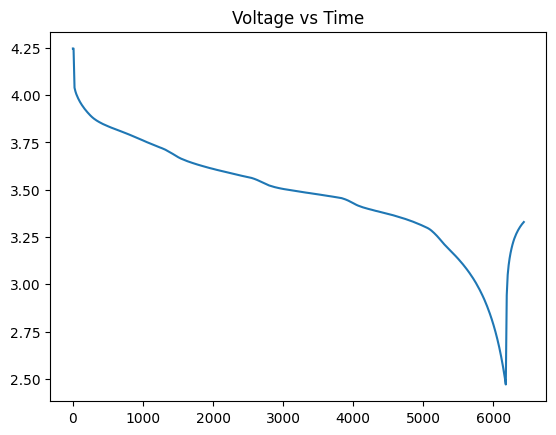

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

plt.plot(df['Time'], df['Voltage_measured'])
plt.title('Voltage vs Time')
plt.show()


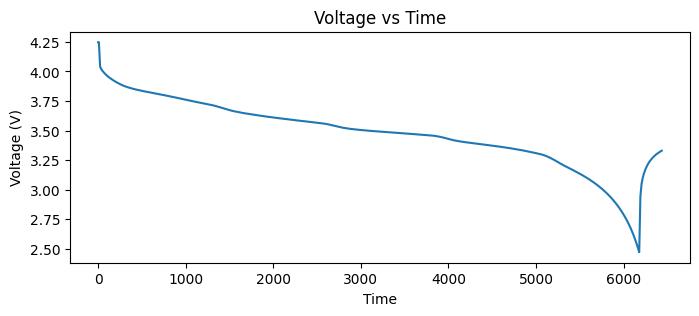

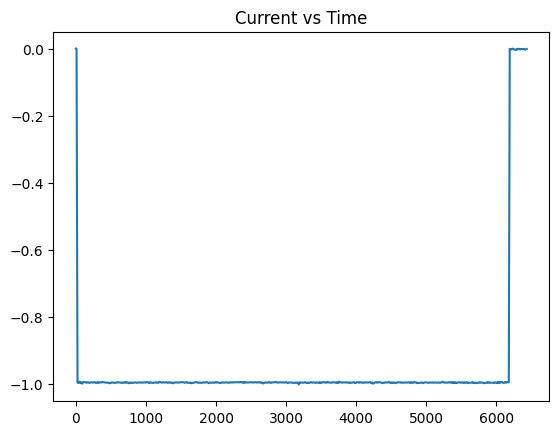

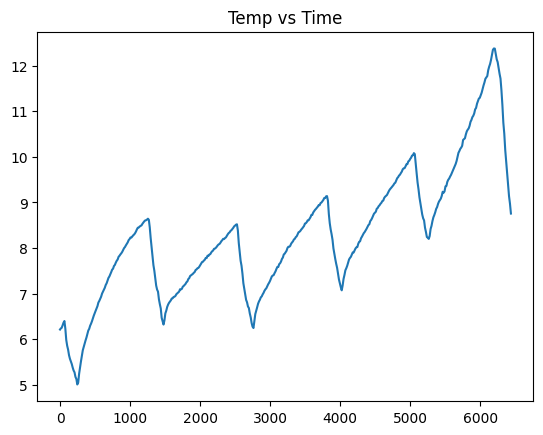

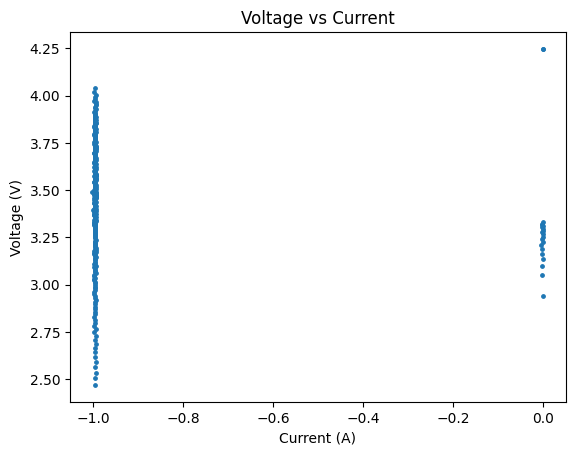

In [33]:
## plots for relationships

import matplotlib.pyplot as plt

# Voltage vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Voltage_measured'])
plt.xlabel('Time'); plt.ylabel('Voltage (V)'); plt.title('Voltage vs Time')
plt.show()

# Current vs Time
plt.plot(df['Time'], df['Current_measured']); plt.title('Current vs Time'); plt.show()

# Temperature vs Time
plt.plot(df['Time'], df['Temperature_measured']); plt.title('Temp vs Time'); plt.show()

# Voltage vs Current scatter
plt.scatter(df['Current_measured'], df['Voltage_measured'], s=6)
plt.xlabel('Current (A)'); plt.ylabel('Voltage (V)'); plt.title('Voltage vs Current'); plt.show()


In [34]:
# Create new features
df['Power'] = df['Voltage_measured'] * df['Current_measured']   
df['Delta_t'] = df['Time'].diff().fillna(0)                    
df['Energy_increment'] = df['Power'] * df['Delta_t']           
df['Energy_total'] = df['Energy_increment'].cumsum()          

print(df.head())


   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time     Power  Delta_t  Energy_increment  Energy_total  
0         0.000   0.000  0.001072    0.000          0.000000      0.000000  
1         4.262   9.360 -0.005992    9.360         -0.056089     -0.056089  
2         3.465  23.281 -4.019458   13.921        -55.954874    -56.010964  
3         3.451  36.406 -4.006367   13.125        -52.583566   -108.594529  
4         3.438  49.625 -3.976108   13.219        -52.560168   -161.154697  


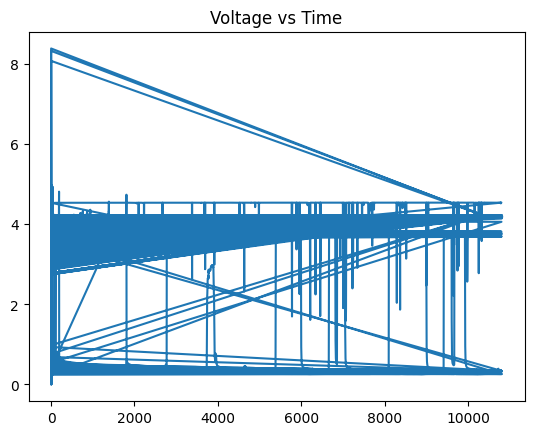

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

plt.plot(cleaned_data['Time'], cleaned_data['Voltage_measured'])
plt.title('Voltage vs Time')
plt.show()


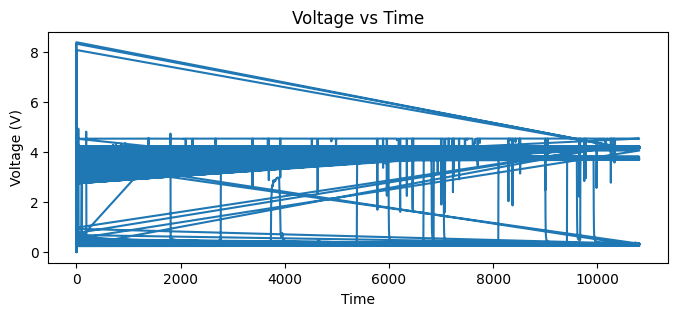

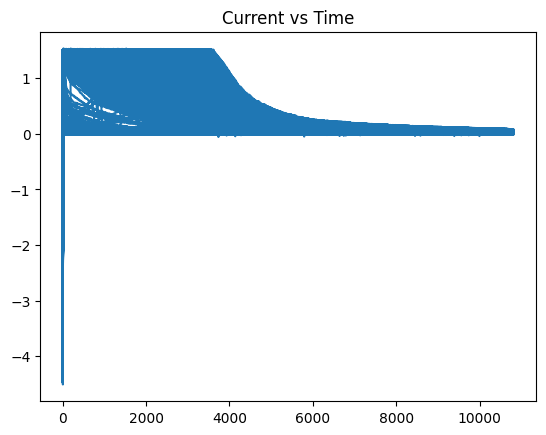

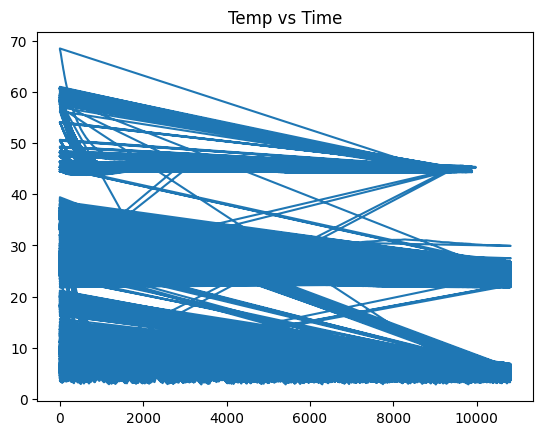

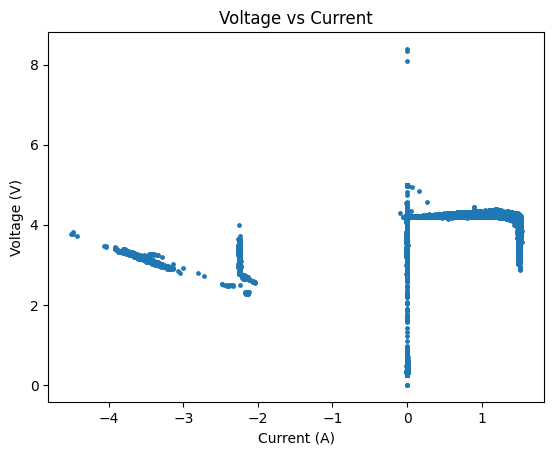

In [36]:
# plots for relationships

import matplotlib.pyplot as plt

# Voltage vs Time
plt.figure(figsize=(8,3))
plt.plot(cleaned_data['Time'], cleaned_data['Voltage_measured'])
plt.xlabel('Time'); plt.ylabel('Voltage (V)'); plt.title('Voltage vs Time')
plt.show()

# Current vs Time
plt.plot(cleaned_data['Time'], cleaned_data['Current_measured']); plt.title('Current vs Time'); plt.show()

# Temperature vs Time
plt.plot(cleaned_data['Time'], cleaned_data['Temperature_measured']); plt.title('Temp vs Time'); plt.show()

# Voltage vs Current scatter
plt.scatter(cleaned_data['Current_measured'], cleaned_data['Voltage_measured'], s=6)
plt.xlabel('Current (A)'); plt.ylabel('Voltage (V)'); plt.title('Voltage vs Current'); plt.show()


In [37]:
print("cleaned_data" in locals())
print("merged_data" in locals())
print("data_for_model" in locals())
print("plot_data" in locals())
print("df" in locals())


True
True
False
False
True


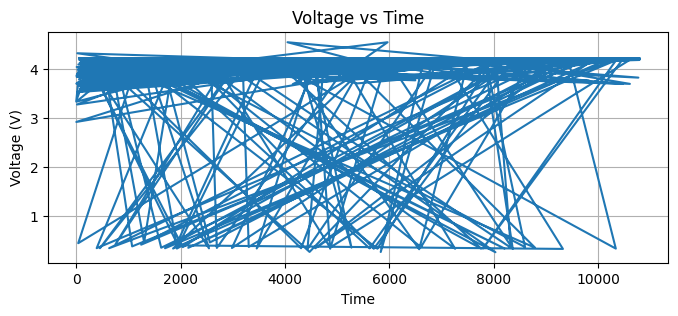

In [38]:
#  Create a fresh copy for plotting
df = cleaned_data.copy()

# Add derived features
df["Power"] = df["Voltage_measured"] * df["Current_measured"]
df["Energy"] = df["Power"] * df["Time"]

#  Handle any missing or infinite values
df = df.replace([float('inf'), -float('inf')], pd.NA).dropna(subset=['Power', 'Energy'])

# Take a small sample to make plotting faster
df = df.sample(5000, random_state=42)

# Plot Voltage vs Time
import matplotlib.pyplot as plt

plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Voltage_measured'])
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.grid(True)
plt.show()


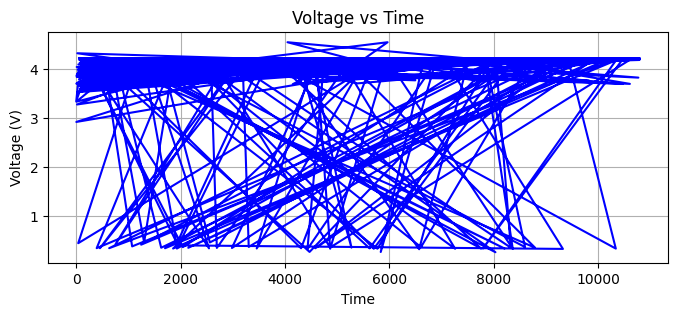

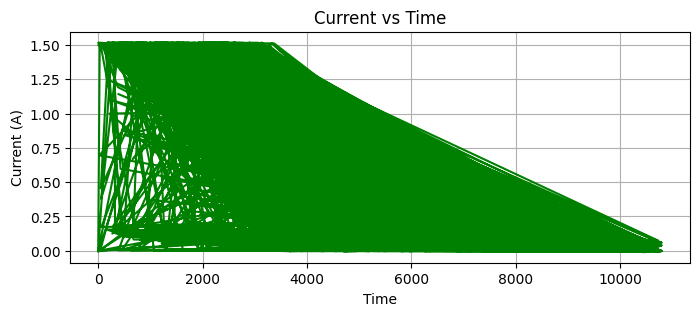

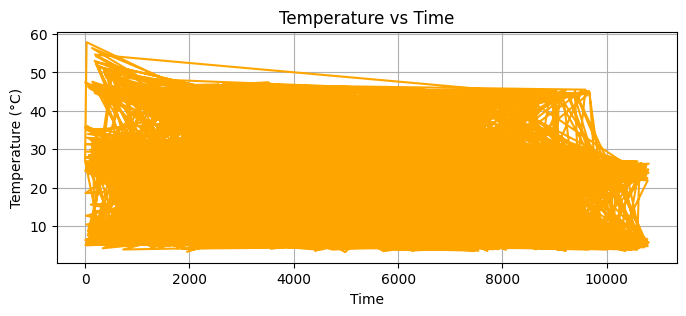

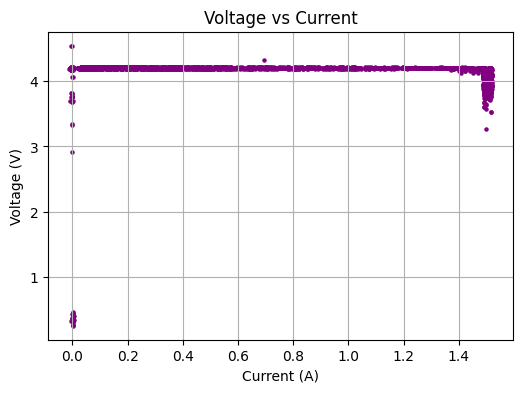

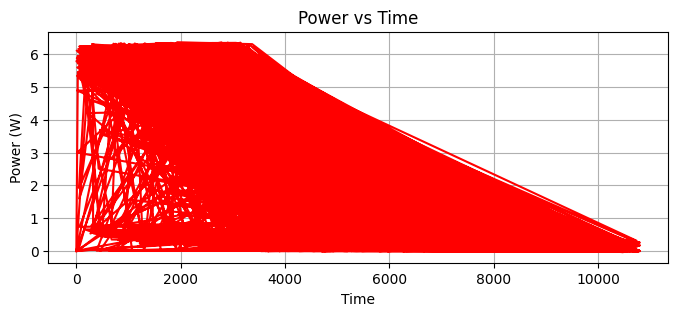

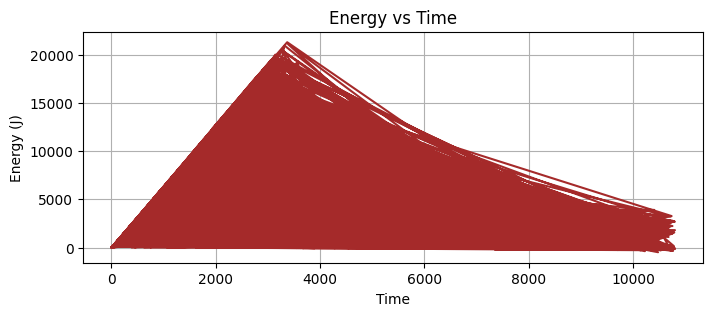

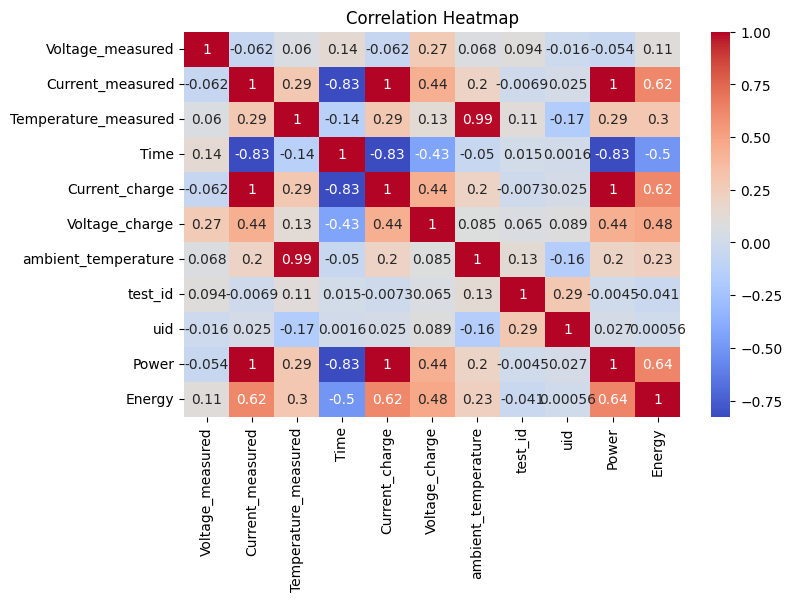

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#  Create a clean working copy
df = cleaned_data.copy()

#  Create Power and Energy columns
df["Power"] = df["Voltage_measured"] * df["Current_measured"]
df["Energy"] = df["Power"] * df["Time"]

# Handle invalid values
df = df.replace([float('inf'), -float('inf')], pd.NA)
df = df.dropna(subset=["Voltage_measured", "Current_measured", "Temperature_measured", "Time", "Power", "Energy"])

# Take a smaller sample for faster plotting (optional)
if len(df) > 5000:
    df = df.sample(5000, random_state=42)

# ---------------- PLOTS ---------------- #

# Voltage vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Voltage_measured'], color='blue')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time')
plt.grid(True)
plt.show()

# Current vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Current_measured'], color='green')
plt.xlabel('Time')
plt.ylabel('Current (A)')
plt.title('Current vs Time')
plt.grid(True)
plt.show()

# Temperature vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Temperature_measured'], color='orange')
plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time')
plt.grid(True)
plt.show()

# Voltage vs Current (scatter)
plt.figure(figsize=(6,4))
plt.scatter(df['Current_measured'], df['Voltage_measured'], s=5, color='purple')
plt.xlabel('Current (A)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Current')
plt.grid(True)
plt.show()

# Power vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Power'], color='red')
plt.xlabel('Time')
plt.ylabel('Power (W)')
plt.title('Power vs Time')
plt.grid(True)
plt.show()

# Energy vs Time
plt.figure(figsize=(8,3))
plt.plot(df['Time'], df['Energy'], color='brown')
plt.xlabel('Time')
plt.ylabel('Energy (J)')
plt.title('Energy vs Time')
plt.grid(True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,5))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


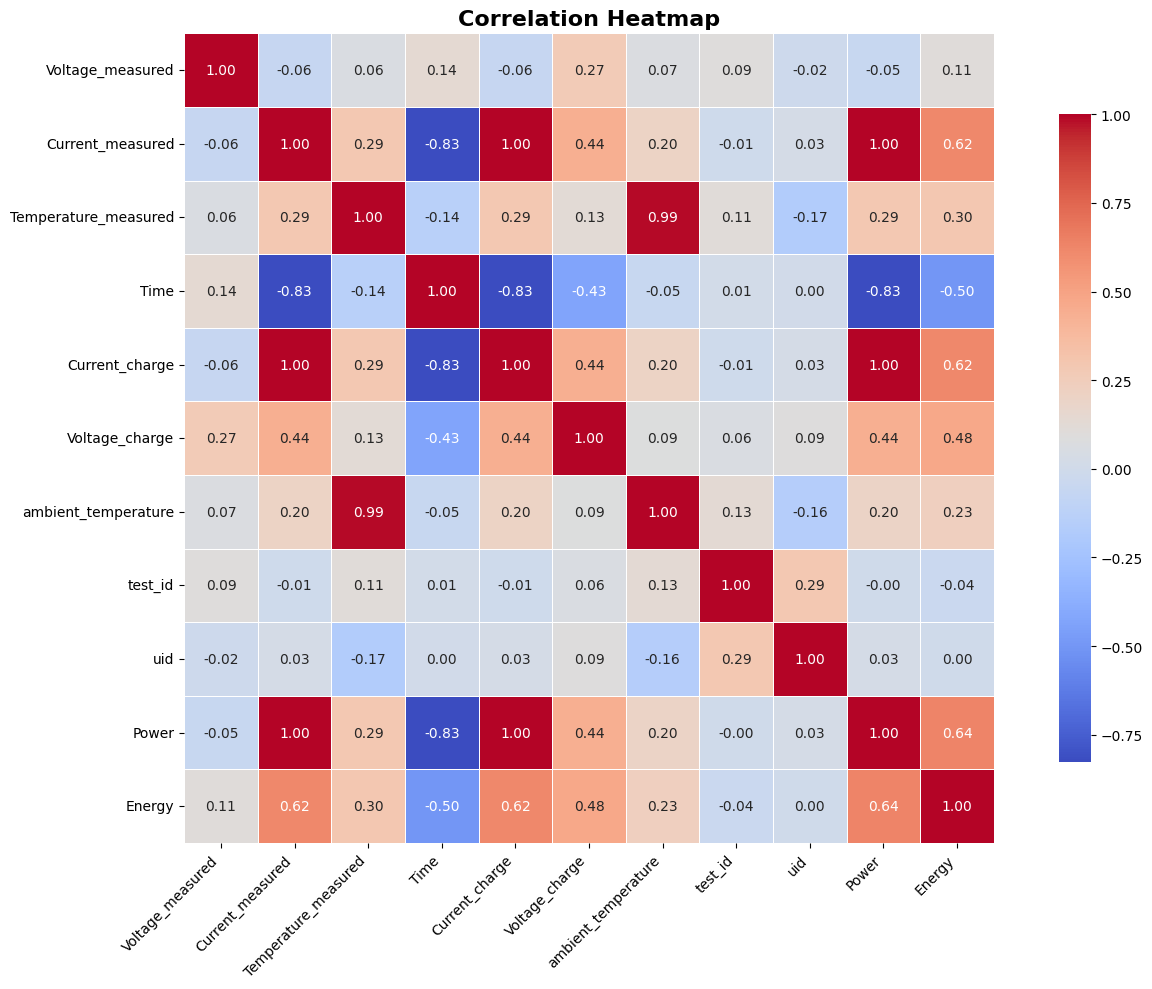

<Axes: >

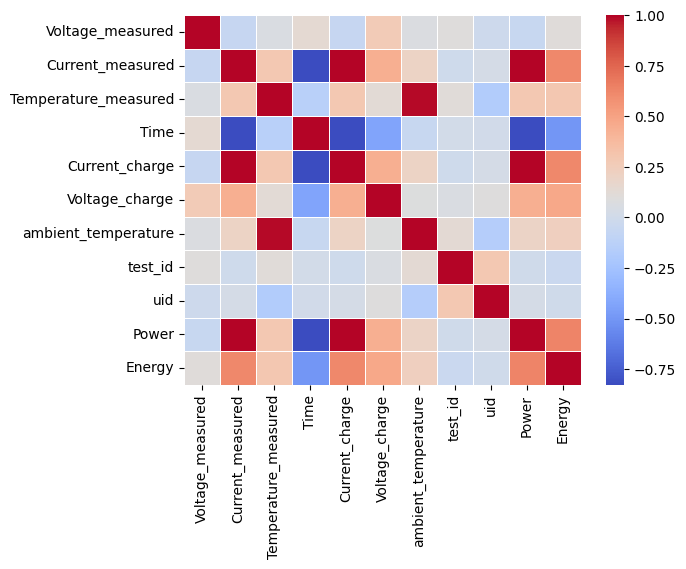

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation
corr = df.corr(numeric_only=True)

# Set up the figure
plt.figure(figsize=(14, 10))  # make it larger

# Draw the heatmap
sns.heatmap(
    corr,
    annot=True,       
    fmt=".2f",       
    cmap='coolwarm',  
    linewidths=0.5,   
    square=True,      
    cbar_kws={'shrink': 0.8}  
)

# Titles and labels
plt.title("Correlation Heatmap", fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)



In [41]:
import sys
print(sys.executable)


c:\Users\asus\AppData\Local\Programs\Python\Python311\python.exe


In [42]:
!c:\Users\asus\AppData\Local\Programs\Python\Python311\python.exe -m pip install scikit-learn --upgrade


In [43]:
# Step 1: generate synthetic battery dataset
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

np.random.seed(42)

n = 5000 
start = datetime.now()

rows = []
for i in range(n):
    ts = start + timedelta(minutes=int(i*5 + np.random.randint(-2,3)))

    cycle_count = int(np.random.exponential(scale=200) * (i/n) + np.random.randint(0,200))

    temperature = np.clip(np.random.normal(loc=28, scale=4), 5, 60)

    current = np.random.normal(loc=1.0, scale=3.0)

    soc = np.clip(np.random.beta(a=2, b=2) * 100, 0, 100)

    voltage = np.clip(3.0 + (soc/100)*(4.2-3.0) + np.random.normal(scale=0.02), 2.5, 4.25)

    base_ir = 0.02
    internal_resistance = base_ir + (cycle_count * 1e-4) + (temperature - 25) * 5e-5 + np.random.normal(scale=0.001)
    internal_resistance = max(0.005, internal_resistance)

    soh_base = 100 - cycle_count * 0.02
    temp_penalty = max(0, temperature - 25) * 0.1
    ir_penalty = internal_resistance * 15
    noise = np.random.normal(scale=0.5)
    soh = soh_base - temp_penalty - ir_penalty + noise
    soh = float(np.clip(soh, 5, 100))

    remaining_life_percent = float(np.clip(soh - np.random.normal(scale=1.0), 0, 100))

    rows.append({
        "timestamp": ts,
        "voltage": round(voltage, 3),
        "current": round(current, 3),
        "temperature": round(temperature, 2),
        "soc": round(soc, 2),
        "cycle_count": int(cycle_count),
        "internal_resistance": round(internal_resistance, 5),
        "soh": round(soh, 2),
        "remaining_life_percent": round(remaining_life_percent, 2)
    })

df = pd.DataFrame(rows)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

csv_path = "01_2_synthetic.csv"
df.to_csv(csv_path, index=False)

print("Synthetic dataset saved to:", csv_path)
print(df.head().to_string(index=False))
print("\nDataframe shape:", df.shape)


Synthetic dataset saved to: 01_2_synthetic.csv
                 timestamp  voltage  current  temperature   soc  cycle_count  internal_resistance   soh  remaining_life_percent
2026-05-18 01:29:07.760112    3.579   -0.259        30.64 48.75          102              0.03071 96.73                   96.51
2026-05-21 19:53:07.760112    3.710    6.979        29.72 57.64          173              0.03860 95.33                   94.93
2026-05-22 01:30:07.760112    3.558    4.727        30.36 44.50          152              0.03600 96.44                   96.57
2026-05-16 12:18:07.760112    3.824    4.043        27.44 70.55           54              0.02541 98.63                   98.80
2026-05-15 07:10:07.760112    4.090    1.748        26.90 91.06          225              0.04397 94.15                   95.82

Dataframe shape: (5000, 9)


In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split


df = pd.read_csv("01_2_synthetic.csv")   # file already exists in your notebook

# Split 75% train / 25% test
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42, shuffle=True)

train_df.to_csv("train_75.csv", index=False)
test_df.to_csv("test_25.csv", index=False)

print("Files saved successfully:")
print("train_75.csv size:", train_df.shape)
print("test_25.csv size:", test_df.shape)


Files saved successfully:
train_75.csv size: (3750, 9)
test_25.csv size: (1250, 9)


In [45]:
import pandas as pd

df = pd.read_csv("train_75.csv")
print(df.columns)
df.head()


Index(['timestamp', 'voltage', 'current', 'temperature', 'soc', 'cycle_count',
       'internal_resistance', 'soh', 'remaining_life_percent'],
      dtype='object')


,timestamp,voltage,current,temperature,soc,cycle_count,internal_resistance,soh,remaining_life_percent
0,2026-05-14 19:20:07.760112,3.860,4.471,27.94,71.84,102,0.03146,97.54,96.14
1,2026-05-25 15:30:07.760112,3.961,0.385,33.67,79.08,220,0.04278,94.27,94.84
2,2026-05-14 01:55:07.760112,3.323,-2.195,24.94,28.57,123,0.03059,97.41,98.73
3,2026-05-21 14:50:07.760112,3.871,2.296,22.67,74.30,338,0.05445,92.51,92.27
4,2026-05-16 08:16:07.760112,3.337,5.351,31.92,25.23,145,0.03422,94.92,96.47


In [46]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# Load training and testing data
train_df = pd.read_csv("train_75.csv")
test_df = pd.read_csv("test_25.csv")

X_train = train_df[["voltage", "current", "temperature", "cycle_count"]]
y_train = train_df["soh"]

X_test = test_df[["voltage", "current", "temperature", "cycle_count"]]
y_test = test_df["soh"]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# Save model + scaler
joblib.dump(model, "soh_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")


MAE: 0.4346705066666613
R² Score: 0.9644743241904478
Model and scaler saved successfully.


In [47]:

# LOAD DATASET

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import joblib

df = pd.read_csv("01_2_synthetic.csv")

# Features and targets
features = ["voltage", "current", "temperature", "soc", "cycle_count", "internal_resistance"]

X = df[features]
y_soh = df["soh"]
y_life = df["remaining_life_percent"]

# TRAIN–TEST SPLIT

X_train, X_test, y_train_soh, y_test_soh = train_test_split(
    X, y_soh, test_size=0.25, random_state=42, shuffle=True
)

_, _, y_train_life, y_test_life = train_test_split(
    X, y_life, test_size=0.25, random_state=42, shuffle=True
)


# SCALING 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.pkl")


# TRAIN MODELS

soh_model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
life_model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)

soh_model.fit(X_train_scaled, y_train_soh)
life_model.fit(X_train_scaled, y_train_life)


# EVALUATE

def evaluate(model, X, y, name):
    pred = model.predict(X)
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    print(f"\n📊 {name} Model")
    print("MAE:", mae)
    print("R² Score:", r2)

evaluate(soh_model, X_test_scaled, y_test_soh, "SOH")
evaluate(life_model, X_test_scaled, y_test_life, "Remaining Life")


#  SAVE MODELS
joblib.dump(soh_model, "soh_model.pkl")
joblib.dump(life_model, "life_model.pkl")

print("\nModels saved successfully!")



📊 SOH Model
MAE: 0.4378969811897339
R² Score: 0.9641326078220982

📊 Remaining Life Model
MAE: 0.9346260643055213
R² Score: 0.8758711611517557

Models saved successfully!


In [48]:
def predict_battery(voltage, current, temperature, soc, cycle_count, internal_resistance):
    sample = np.array([[voltage, current, temperature, soc, cycle_count, internal_resistance]])
    sample_scaled = scaler.transform(sample)
    soh = soh_model.predict(sample_scaled)[0]
    life = life_model.predict(sample_scaled)[0]
    return soh, life


2026-05-12 20:25:48.072 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 20:25:48.082 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 20:25:49.288 
  command:

    streamlit run c:\Users\asus\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-12 20:25:49.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 20:25:49.288 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 20:25:49.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-12 20:25:49.330 Thread 'MainThread': missing ScriptRunContext! This war

DeltaGenerator()

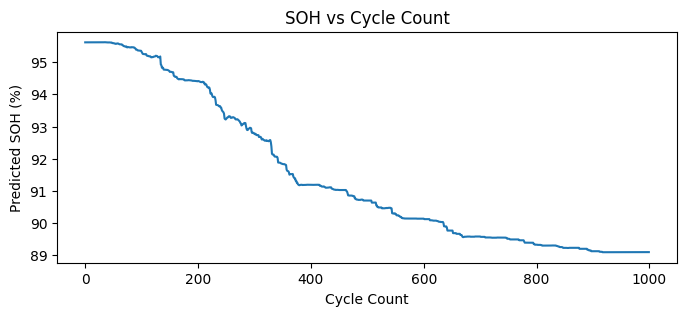

In [49]:
import streamlit as st
import numpy as np
import joblib
import matplotlib.pyplot as plt

# Load ML models and scaler
soh_model = joblib.load("soh_model.pkl")
life_model = joblib.load("life_model.pkl")
scaler = joblib.load("scaler.pkl")

st.set_page_config(page_title="Smart BMS Dashboard", layout="wide")

st.title("🔋 Smart BMS – Battery Health Monitoring Dashboard")
st.write("Real-time State of Health (SOH) & remaining life predictions using Machine Learning.")


# Input Section

st.subheader("📥 Sensor Inputs")

col1, col2, col3 = st.columns(3)

with col1:
    voltage = st.slider("Voltage (V)", 2.8, 4.2, 3.9)
    soc = st.slider("State of Charge (%)", 0, 100, 80)

with col2:
    current = st.slider("Current (A)", 0.0, 5.0, 1.0)
    cycle_count = st.slider("Cycle Count", 0, 1000, 150)

with col3:
    temperature = st.slider("Temperature (°C)", 10, 60, 30)
    internal_resistance = st.slider("Internal Resistance (Ω)", 0.01, 0.20, 0.05)

# Prediction

sample = np.array([[voltage, current, temperature, soc, cycle_count, internal_resistance]])
sample_scaled = scaler.transform(sample)

soh = soh_model.predict(sample_scaled)[0]
life = life_model.predict(sample_scaled)[0]



# Color Logic for SOH & Life

def get_color(value):
    if value > 80:
        return "🟢"
    elif value > 50:
        return "🟡"
    else:
        return "🔴"

soh_color = get_color(soh)
life_color = get_color(life)

# Output Metrics

colA, colB = st.columns(2)

with colA:
    st.metric("🔋 State of Health (SOH)", f"{soh:.2f}%", delta=None)
    st.write(f"Status: {soh_color} **{ 'Healthy' if soh_color=='🟢' else 'Moderate' if soh_color=='🟡' else 'Critical' }**")

with colB:
    st.metric("⏳ Remaining Life (%)", f"{life:.2f}%", delta=None)
    st.write(f"Status: {life_color} **{ 'Long Life' if life_color=='🟢' else 'Mid Life' if life_color=='🟡' else 'End of Life' }**")


# Alerts (Safety System)

st.subheader("⚠️ Safety Alerts")

alerts = []

if temperature > 45:
    alerts.append("🔥 **Overheating detected! (>45°C)**")

if current > 3.5:
    alerts.append("⚡ **High current flow! (>3.5A)**")

if internal_resistance > 0.15:
    alerts.append("🛑 **Internal resistance is abnormally high!**")

if soh < 50:
    alerts.append("🔋 **SOH is critically low. Consider battery replacement.**")

if len(alerts) == 0:
    st.success("All conditions normal. Battery operating safely.")
else:
    for a in alerts:
        st.error(a)


# Graph: SOH vs Cycle Count (Prediction Curve)

st.subheader("📉 Predicted SOH Degradation Curve")

cycles = np.arange(0, 1000)
curve_input = np.array([[voltage, current, temperature, soc, c, internal_resistance] for c in cycles])
curve_scaled = scaler.transform(curve_input)
soh_curve = soh_model.predict(curve_scaled)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(cycles, soh_curve)
ax.set_title("SOH vs Cycle Count")
ax.set_xlabel("Cycle Count")
ax.set_ylabel("Predicted SOH (%)")
st.pyplot(fig)

st.write("---")
st.caption("Smart BMS powered by Machine Learning")
